In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mehulkumar99/schema-lookup-spider-dataset/schema_lookup.json
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/train_spider.json
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/train_others.json
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/dev_gold.sql
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/dev.json
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/README.txt
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/train_gold.sql
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/tables.json
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/database/solvency_ii/solvency_ii.sqlite
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/database/solvency_ii/sch

In [ ]:
import warnings
import transformers
transformers.logging.set_verbosity_error()
warnings.filterwarnings("ignore")

In [ ]:
import os
# This will list everything actually on the disk right now
!ls -R /kaggle/working/llama-3-1-clean

# pip installs

In [ ]:
# 1. Force upgrade the hub first to resolve the 'KernelInfo' mismatch
!pip install --upgrade huggingface_hub

In [ ]:
!pip install "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.29" "trl<0.13.0" peft accelerate bitsandbytes

In [2]:
import os
from huggingface_hub import snapshot_download

# This is a safe, visible directory
local_model_path = "/kaggle/working/llama-3-1-clean"

snapshot_download(
    repo_id="unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    local_dir=local_model_path,
    local_dir_use_symlinks=False, # FORCES real files, no broken pointers
    resume_download=True
)

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

'/kaggle/working/llama-3-1-clean'

# LOADING LLAMA 8.1

In [3]:
from unsloth import FastLanguageModel
import torch
from peft import PeftModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name   = "/kaggle/working/llama-3-1-clean", # No more cache!
    max_seq_length = 2048,
    dtype        = None,
    load_in_4bit = True,
    device_map = {"":0} # multi-GPU sharding is making your inference slower. forcing everything on cuda:0
) 


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


[unsloth_zoo.log|WARNING]Unsloth: Could not patch trl.trainer.ppov2_trainer: Direct module loading failed for UnslothPPOv2Trainer: duplicate argument 'kwargs' in function definition (UnslothPPOv2Trainer.py, line 369)


==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load /kaggle/working/llama-3-1-clean as a legacy tokenizer.


In [4]:
# Apply LoRA adapters

adapter_path = '/kaggle/input/notebooks/mehulkumar99/spider-question-to-sql-query/outputs/checkpoint-200/'
model = PeftModel.from_pretrained(model, adapter_path)

print(f"Memory used: {model.get_memory_footprint()/1e9:.2f} GB")
model.print_trainable_parameters()

Memory used: 5.76 GB
trainable params: 0 || all params: 8,072,204,288 || trainable%: 0.0000


# Loading validation set

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset("spider")
validation_df = pd.DataFrame(dataset['validation'])
train_df = pd.DataFrame(dataset['train'])
validation_df.head(3)

README.md: 0.00B [00:00, ?B/s]

spider/train-00000-of-00001.parquet:   0%|          | 0.00/831k [00:00<?, ?B/s]

spider/validation-00000-of-00001.parquet:   0%|          | 0.00/126k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1034 [00:00<?, ? examples/s]

,db_id,query,question,query_toks,query_toks_no_value,question_toks
0,concert_singer,SELECT count(*) FROM singer,How many singers do we have?,"[SELECT, count, (, *, ), FROM, singer]","[select, count, (, *, ), from, singer]","[How, many, singers, do, we, have, ?]"
1,concert_singer,SELECT count(*) FROM singer,What is the total number of singers?,"[SELECT, count, (, *, ), FROM, singer]","[select, count, (, *, ), from, singer]","[What, is, the, total, number, of, singers, ?]"
2,concert_singer,"SELECT name , country , age FROM singer ORDE...","Show name, country, age for all singers ordere...","[SELECT, name, ,, country, ,, age, FROM, singe...","[select, name, ,, country, ,, age, from, singe...","[Show, name, ,, country, ,, age, for, all, sin..."


# Loading schema dataset

In [6]:
spider_tables = load_dataset("richardr1126/spider-schema", split="train")
df= pd.DataFrame(spider_tables)

print(spider_tables)

README.md: 0.00B [00:00, ?B/s]

spider_schema_rows_v2.json: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['db_id', 'Schema (values (type))', 'Primary Keys', 'Foreign Keys'],
    num_rows: 166
})


In [7]:
schema_lookup ={}
for row in spider_tables:
  schema_lookup[row['db_id']]= row

schema_lookup['csu_1']

{'db_id': 'csu_1',
 'Schema (values (type))': 'Campuses : Id (number) , Campus (text) , Location (text) , County (text) , Year (number) | csu_fees : Campus (number) , Year (number) , CampusFee (number) | degrees : Year (number) , Campus (number) , Degrees (number) | discipline_enrollments : Campus (number) , Discipline (number) , Year (number) , Undergraduate (number) , Graduate (number) | enrollments : Campus (number) , Year (number) , TotalEnrollment_AY (number) , FTE_AY (number) | faculty : Campus (number) , Year (number) , Faculty (number)',
 'Primary Keys': 'Campuses : Id | csu_fees : Campus | degrees : Year | discipline_enrollments : Campus | enrollments : Campus',
 'Foreign Keys': 'csu_fees : Campus equals Campuses : Id | degrees : Campus equals Campuses : Id | discipline_enrollments : Campus equals Campuses : Id | enrollments : Campus equals Campuses : Id | faculty : Campus equals Campuses : Id'}

In [8]:
type(schema_lookup)

dict

## Understanding table Counts

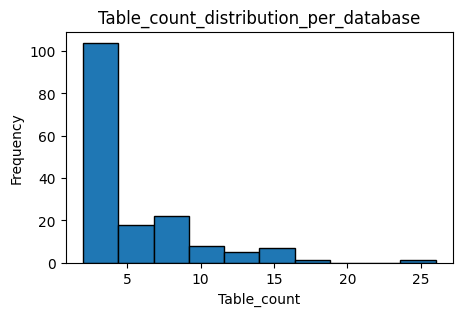

mean count of tables is : 5.27710843373494


In [11]:
import numpy as np
def total_tables(schema):
    count = 0
    count = sum(1 for char in schema if char =='|')
    return count+1

# total_tables = total_tables('Campuses : Id (number) , Campus (text) , Location (text) , County (text) , Year (number) | csu_fees : Campus (number) , Year (number) , CampusFee (number) | degrees : Year (number) , Campus (number) , Degrees (number) | discipline_enrollments : Campus (number) , Discipline (number) , Year (number) , Undergraduate (number) , Graduate (number) | enrollments : Campus (number) , Year (number) , TotalEnrollment_AY (number) , FTE_AY (number) | faculty : Campus (number) , Year (number) , Faculty (number)')
# total_tables
    
df['count_tables'] = df['Schema (values (type))'].apply(total_tables)
count_tables = df['count_tables'].tolist()

import matplotlib.pyplot as plt
plt.figure(figsize=(5, 3))
# Create the histogram
plt.hist(count_tables, bins=10, edgecolor='black')

# Add labels and title
plt.title('Table_count_distribution_per_database')
plt.xlabel('Table_count')
plt.ylabel('Frequency')

# Display the plot
plt.show()
print(f'mean count of tables is : {np.mean(count_tables)}')

    

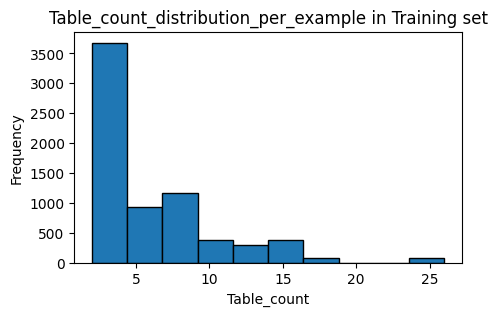

mean count of tables in training_set : 6.035714285714286


In [12]:

train_df['schema'] = train_df['db_id'].apply(lambda db_id: schema_lookup[db_id]['Schema (values (type))'] )

train_df['count_tables'] = train_df['schema'].apply(total_tables)
count_tables = train_df['count_tables'].tolist()

import matplotlib.pyplot as plt
plt.figure(figsize=(5, 3))
# Create the histogram
plt.hist(count_tables, bins=10, edgecolor='black')

# Add labels and title
plt.title('Table_count_distribution_per_example in Training set')
plt.xlabel('Table_count')
plt.ylabel('Frequency')

# Display the plot
plt.show()
print(f'mean count of tables in training_set : {np.mean(count_tables)}')


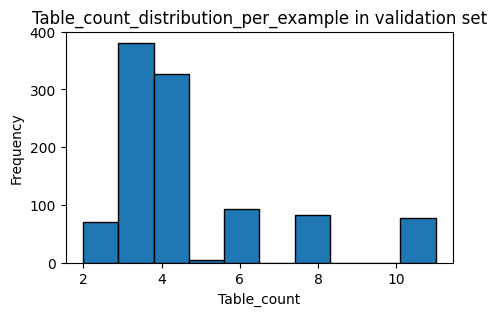

mean count of tables in validation_set : 4.52321083172147


In [13]:

validation_df['schema'] =       validation_df['db_id'].apply(lambda db_id: schema_lookup[db_id]['Schema (values (type))'] )
validation_df['count_tables'] = validation_df['schema'].apply(total_tables)
count_tables = validation_df['count_tables'].tolist()

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
# Create the histogram
plt.hist(count_tables, bins=10, edgecolor='black')

# Add labels and title
plt.title('Table_count_distribution_per_example in validation set')
plt.xlabel('Table_count')
plt.ylabel('Frequency')

# Display the plot

plt.show()
print(f'mean count of tables in validation_set : {np.mean(count_tables)}')


## Loading schema_lookup

In [14]:
import json

# Update this name to match whatever you named your dataset
input_path = "/kaggle/input/datasets/mehulkumar99/schema-lookup-spider-dataset/schema_lookup.json"

with open(input_path, "r") as f:
    schema_lookup = json.load(f)

print(f"Loaded schema for {len(schema_lookup)} databases.")

Loaded schema for 166 databases.


In [15]:
schema_lookup['csu_1']['format_schema']

'# Table: Campuses \n## Columns:\n- Id (number, PK)\n- Campus (text)\n- Location (text)\n- County (text)\n- Year (number)\n\n# Table: csu_fees \n## Columns:\n- Campus (number, PK, FK -> Campuses.Id)\n- Year (number)\n- CampusFee (number)\n\n# Table: degrees \n## Columns:\n- Year (number, PK)\n- Campus (number, FK -> Campuses.Id)\n- Degrees (number)\n\n# Table: discipline_enrollments \n## Columns:\n- Campus (number, PK, FK -> Campuses.Id)\n- Discipline (number)\n- Year (number)\n- Undergraduate (number)\n- Graduate (number)\n\n# Table: enrollments \n## Columns:\n- Campus (number, PK, FK -> Campuses.Id)\n- Year (number)\n- TotalEnrollment_AY (number)\n- FTE_AY (number)\n\n# Table: faculty \n## Columns:\n- Campus (number, FK -> Campuses.Id)\n- Year (number)\n- Faculty (number)'

# BUILDING PROMPT

In [16]:
def build_prompt( schema_lookup, index, dataset, inference = False ):

    df = dataset
    prompt = ''

    db_id = df['db_id'][index]
    question = df['question'][index]
    schema = schema_lookup[db_id]['format_schema']
    
    prompt = f"""<|start_header_id|>system<|end_header_id|>

Convert the natural language question to SQL using the schema below. Use SQLite syntax and SQLite functions only.{tokenizer.eos_token}<|start_header_id|>user<|end_header_id|>

### Schema:
{schema}

### Question:
{question + tokenizer.eos_token}"""

    if inference == True:
        text = prompt + "<|start_header_id|>assistant<|end_header_id|>\n\n"
        return {'text': text}

    elif inference == False:
        query = df['query'][index]
        text = prompt+ f"""<|start_header_id|>assistant<|end_header_id|>

{query + tokenizer.eos_token}"""
        
        return {'text':text}
    return{'text': prompt}

# train_df = pd.DataFrame(dataset['train'])
# validation_df = pd.DataFrame(dataset['validation'])

text = build_prompt( schema_lookup, index =0,dataset = validation_df, inference = True )
print(text)
    

{'text': '<|start_header_id|>system<|end_header_id|>\n\nConvert the natural language question to SQL using the schema below. Use SQLite syntax and SQLite functions only.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n### Schema:\n# Table: stadium \n## Columns:\n- Stadium_ID (number, PK)\n- Location (text)\n- Name (text)\n- Capacity (number)\n- Highest (number)\n- Lowest (number)\n- Average (number)\n\n# Table: singer \n## Columns:\n- Singer_ID (number, PK)\n- Name (text)\n- Country (text)\n- Song_Name (text)\n- Song_release_year (text)\n- Age (number)\n- Is_male (others)\n\n# Table: concert \n## Columns:\n- concert_ID (number, PK)\n- concert_Name (text)\n- Theme (text)\n- Stadium_ID (text, FK -> stadium.Stadium_ID)\n- Year (text)\n\n# Table: singer_in_concert \n## Columns:\n- concert_ID (number, PK, FK -> concert.concert_ID)\n- Singer_ID (text, FK -> singer.Singer_ID)\n\n### Question:\nHow many singers do we have?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'}


# DATA LOADER PREP

In [17]:
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

# Step 1 — build prompts WITHOUT the answer (inference=True)
inference_texts = []
for i in range(len(validation_df)):
    result = build_prompt(schema_lookup, i, validation_df, inference=True)
    inference_texts.append(result['text'])

# Step 2 — tokenize all prompts
tokenized = tokenizer(
    inference_texts,
    truncation=True,
    max_length=2048,
    padding=False,          # don't pad yet — DataLoader will handle per batch
    add_special_tokens= True,
    return_tensors=None,    # return list, not tensors
)

# Step 3 — build a simple dataset
from datasets import Dataset
inference_dataset = Dataset.from_dict({
    'input_ids': tokenized['input_ids'],
    'attention_mask': tokenized['attention_mask'],
})

tokenizer.padding_side = 'left'

# Step 4 — use DataCollatorWithPadding to batch and pad
collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    return_tensors='pt',
)

dataloader = DataLoader(
    inference_dataset,
    batch_size=16,
    shuffle=False,           # keep order so predictions align with val_df rows
    collate_fn=collator,
)

In [18]:
# from torch.utils.data import DataLoader
# from transformers import DataCollatorWithPadding

# # Step 1 — build prompts WITHOUT the answer (inference=True)
# inference_texts = []
# for i in range(len(validation_df)):
#     result = build_prompt(schema_lookup, i, validation_df, inference=True)
#     inference_texts.append(result['text'])

In [19]:
# tokenizer.padding_side = 'left'
# tokenized = tokenizer(
#     inference_texts,
#     truncation=True,
#     max_length=2048,
#     padding=False,          # don't pad yet — DataLoader will handle per batch
#     add_special_tokens= True,
#     return_tensors=None,    # return list, not tensors
# )
# print(len(tokenized['input_ids']))
# print(list(tokenized.keys()))

Dataset.from_dict takes the keys from your dictionary (input_ids, attention_mask) and turns them into Columns. Each item in the list becomes a Row.

Row 1: input_ids for your first SQL prompt, attention_mask for your first SQL prompt.

Row 2: input_ids for your second SQL prompt

In [20]:
# from datasets import Dataset
# inference_dataset = Dataset.from_dict({
#     'input_ids': tokenized['input_ids'],
#     'attention_mask': tokenized['attention_mask'],
# })
# print(inference_dataset.column_names)
# print(len(inference_dataset))

In [21]:
# collator = DataCollatorWithPadding(
#     tokenizer=tokenizer,
#     padding=True,
#     return_tensors='pt',
# )
# print(collator.tokenizer.pad_token_id) # shows the pad_token_id used by the token

In [22]:
# dataloader = DataLoader(
#     inference_dataset,
#     batch_size=16,
#     shuffle=False,           # keep order so predictions align with val_df rows
#     collate_fn=collator,
# )

In [23]:
# 1. Grab one batch
batch = next(iter(dataloader))

# 2. Get the pad token ID from your tokenizer
pad_id = tokenizer.pad_token_id

# 3. Inspect the first few tokens of the first row in the batch
# If it's Left Padding, the first few numbers should be the pad_id
print(f"Pad Token ID: {pad_id}")
print(f"First 10 tokens of row 0: {batch['input_ids'][1][:10].tolist()}")
print(f"Last 10 tokens of row 0:  {batch['input_ids'][1][-10:].tolist()}")

# 4. Logical check
is_left = batch['input_ids'][0][0] == pad_id
print(f"\nIs it Left Padded? {is_left}")

print(f'length of the first batch: {len(batch['input_ids'][1])}')

Pad Token ID: 128004
First 10 tokens of row 0: [128004, 128004, 128004, 128004, 128004, 128004, 128004, 128004, 128004, 128004]
Last 10 tokens of row 0:  [2860, 1396, 315, 68141, 30, 128009, 128006, 78191, 128007, 271]

Is it Left Padded? True
length of the first batch: 241


# GENERATION

In [25]:
import time
torch.cuda.reset_peak_memory_stats()

start = time.time()
batch = next(iter(dataloader))
input_ids = batch['input_ids'].to(model.device)
attention_mask = batch['attention_mask'].to(model.device)

with torch.no_grad():
    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=128,
        do_sample=False,
        use_cache=True,
        eos_token_id=tokenizer.convert_tokens_to_ids("<|eot_id|>"),
        pad_token_id=tokenizer.pad_token_id,
    )

elapsed = time.time() - start
peak = torch.cuda.max_memory_allocated() / 1024**3
print(f"Time: {elapsed:.1f}s, Peak memory: {peak:.2f}GB")

Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.1

Time: 13.8s, Peak memory: 8.20GB


In [26]:
len(outputs[15])

266

In [27]:
tokenizer.decode(outputs[15])

'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nConvert the natural language question to SQL using the schema below. Use SQLite syntax and SQLite functions only.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n### Schema:\n# Table: stadium \n## Columns:\n- Stadium_ID (number, PK)\n- Location (text)\n- Name (text)\n- Capacity (number)\n- Highest (number)\n- Lowest (number)\n- Average (number)\n\n# Table: singer \n## Columns:\n- Singer_ID (number, PK)\n- Name (text)\n- Country (text)\n- Song_Name (text)\n- Song_release_year (text)\n- Age (number)\n- Is_male (others)\n\n# Table: concert \n## Columns:\n- concert_ID (number, PK)\n- concert_Name (text)\n- Theme (text)\n- Stadium_ID (text, FK -> stadium.Stadium_ID)\n- Year (text)\n\n# Table: singer_in_concert \n## Columns:\n- concert_ID (number, PK, FK -> concert.concert_ID)\n- Singer_ID (text, FK -> singer.Singer_ID)\n\n### Question:\nWhat are the locations and names of all stations with capacity between 5000 and 10000?<

In [28]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [32]:
# from unsloth import FastLanguageModel

# FastLanguageModel.for_inference(model)  # unsloth inference mode — 2x faster

from tqdm.auto import tqdm
predictions = []

model.eval()
for batch in tqdm(dataloader, desc = 'Generating'):
    input_ids      = batch['input_ids'].to(model.device)
    attention_mask = batch['attention_mask'].to(model.device)

    # GREEDY SEARCH
    with torch.no_grad():
        outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=128,
        do_sample=False,        # greedy
        use_cache=True,         # works fine with greedy
        eos_token_id=tokenizer.convert_tokens_to_ids("<|eot_id|>"),
        pad_token_id=tokenizer.pad_token_id,
        # temperature=0.2, # Very close to greedy but allows slight variation
        # top_p=0.95,
    )

    for i, output in enumerate(outputs):
        # print(output)
        actual_prompt_len = batch['attention_mask'][i].sum().item()
        generated = output[batch['input_ids'].shape[1]:]
        sql = tokenizer.decode(generated, skip_special_tokens=True).strip()
        if sql.startswith("assistant"):
            sql = sql[len("assistant"):].strip()
        predictions.append(sql)


print(predictions[:3])

Generating:   0%|          | 0/65 [00:00<?, ?it/s]

Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `tr

['SELECT count(*) FROM singer', 'SELECT count(*) FROM singer', 'SELECT name,  country,  age FROM singer ORDER BY age DESC']


In [33]:
import json
with open("/kaggle/working/predictions.json", "w") as f:
    json.dump(predictions, f)

In [34]:
# Save predictions
import pandas as pd
validation_df['predicted_sql'] = predictions
validation_df.to_csv("/kaggle/working/validation_predictions.csv", index=False)

# Save model adapter too if not already saved
model.save_pretrained("/kaggle/working/final_adapter")
tokenizer.save_pretrained("/kaggle/working/final_adapter")

config.json: 0.00B [00:00, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/final_adapter/tokenizer_config.json.


('/kaggle/working/final_adapter/tokenizer_config.json',
 '/kaggle/working/final_adapter/chat_template.jinja',
 '/kaggle/working/final_adapter/tokenizer.json')

# EXECUTING SQL

In [35]:
import sqlite3

KAGGLE_DB_DIR = '/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/database'
def execute_sql(sql, db_id, db_dir = KAGGLE_DB_DIR ):
    
    """Execute SQL against SQLite DB, return result set or None on error."""
    db_path = os.path.join(db_dir, db_id, f"{db_id}.sqlite")

    # CRITICAL: Check if the file actually exists before connecting
    if not os.path.exists(db_path):
        print(f"Warning: Database file not found at {db_path}")
        return None
    try:
        # 'mode=ro' tells SQLite to open it in Read-Only mode
        conn = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)
        cursor = conn.cursor()
        cursor.execute(sql)
        result = cursor.fetchall()
        conn.close()
        return result
    # except Exception as e:
    #     return None   # invalid SQL
    except sqlite3.Error as e:
        # This will return the specific SQLite error message (e.g., "no such column: name")
        print(f"SQL Error on {db_id}: {e}")
        return str(e) 
    except Exception as e:
        # This catches other issues (like file path errors)
        print(f"General Error: {e}")
        return None
    
sql = 'SELECT T1.Continent,  count(*),  T2.ContinentId FROM continents AS T1 JOIN countries AS T2 ON T1.ContId  =  T2.Continent GROUP BY T2.ContinentId'
result = execute_sql(sql, db_id = 'car_1')
print(result)

SQL Error on car_1: no such column: T2.ContinentId
no such column: T2.ContinentId


In [36]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter
import threading

# SQLite connections are not thread-safe, so create one per thread
thread_local = threading.local()

def get_connection(db_path):
    if not hasattr(thread_local, 'connections'):
        thread_local.connections = {}
    if db_path not in thread_local.connections:
        thread_local.connections[db_path] = sqlite3.connect(db_path)
    return thread_local.connections[db_path]

def evaluate_single(args):
    i, predicted, ground_truth, db_id = args
    pred_result  = execute_sql(predicted, db_id)
    truth_result = execute_sql(ground_truth, db_id)
    
    if pred_result is None:
        return i, 'error'
    elif Counter(pred_result) == Counter(truth_result):
        return i, 'correct'
    else:
        return i, 'wrong'

def execution_accuracy_parallel(validation_df, predictions, max_workers=4):
    total   = len(validation_df)
    correct = 0
    errors  = 0

    args_list = [
        (
            i,
            predictions[i],
            validation_df['query'].iloc[i],
            validation_df['db_id'].iloc[i],
        )
        for i in range(total)
    ]

    results = [None] * total

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(evaluate_single, args): args[0] for args in args_list}
        for future in tqdm(as_completed(futures), total=total, desc="Evaluating"):
            i, status = future.result()
            results[i] = status

    correct = sum(1 for r in results if r == 'correct')
    errors  = sum(1 for r in results if r == 'error')
    accuracy = correct / total

    print(f"Execution Accuracy : {accuracy:.4f} ({correct}/{total})")
    print(f"Invalid SQL errors : {errors}/{total}")
    return accuracy

In [37]:
# Step 2 — evaluation (CPU, parallelized, no GPU needed)
accuracy = execution_accuracy_parallel(validation_df, predictions, max_workers=4)


Evaluating:   0%|          | 0/1034 [00:00<?, ?it/s]

SQL Error on car_1: no such column: T2.ContinentId
SQL Error on car_1: no such column: T2.Horsepower
SQL Error on car_1: no such column: T2.year
SQL Error on car_1: no such column: T1.Weight
SQL Error on car_1: no such column: T1.Weight
SQL Error on car_1: no such column: T2.Horsepower
SQL Error on car_1: no such column: T2.ModelId
SQL Error on car_1: no such column: T2.MPG
SQL Error on car_1: no such column: T1.Edispl
SQL Error on car_1: no such column: T1.Edispl
SQL Error on car_1: no such column: T2.ModelId
SQL Error on car_1: no such column: T1.Model
SQL Error on car_1: no such column: T1.cylinders
SQL Error on car_1: no such column: T1.cylinders
SQL Error on car_1: no such column: T3.Maker
SQL Error on car_1: unrecognized token: ""Ford Motor Company"
SQL Error on car_1: no such column: T2.Weight
SQL Error on car_1: SELECTs to the left and right of INTERSECT do not have the same number of result columns
SQL Error on car_1: no such column: T2.country
SQL Error on car_1: misuse of ag

In [ ]:
print(s)